In [1]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Resuming from 1015021568 bytes (1174364851 bytes left)...
100% 2.04G/2.04G [01:05<00:00, 17.8MB/s]

Dataset ready!


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
base_path = "plantvillage/plantvillage dataset/color"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(base_path)
total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

torch.manual_seed(42)
train_indices, val_indices = torch.utils.data.random_split(
    range(total), [train_size, val_size]
)

train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(base_path, transform=train_transform),
    train_indices.indices
)
val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(base_path, transform=val_transform),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 1358 | Val batches: 340


In [4]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(in_features=1280, out_features=38)

# UNFREEZE EVERYTHING — all layers will now learn
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print()
print("Day 6:  only 48,678 params were trainable (frozen backbone)")
print("Day 11: ALL 5,288,548 params are trainable (full fine-tuning)")
print()
print("This is the difference between feature extraction and fine-tuning.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]


Total params:     4,056,226
Trainable params: 4,056,226

Day 6:  only 48,678 params were trainable (frozen backbone)
Day 11: ALL 5,288,548 params are trainable (full fine-tuning)

This is the difference between feature extraction and fine-tuning.


In [5]:
# Day 6 used lr=0.001 — only training the classifier
# Now we're touching pretrained weights — must be careful
# Too high lr = destroys the pretrained knowledge (called 'catastrophic forgetting')
# Low lr = gently nudges the weights in the right direction

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)  # 10x smaller
criterion = nn.CrossEntropyLoss()

print("Learning rate: 0.0001 (10x lower than day6)")
print("Why: We don't want to overwrite what EfficientNet learned from ImageNet.")
print("We want to gently adjust it for plant disease detection.")

Learning rate: 0.0001 (10x lower than day6)
Why: We don't want to overwrite what EfficientNet learned from ImageNet.
We want to gently adjust it for plant disease detection.


In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

print("Functions ready!")

Functions ready!


In [ ]:
NUM_EPOCHS = 5
best_val_acc = 0.0

history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  []}

os.makedirs("model", exist_ok=True)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save only if this is the best val accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "model/best_model.pth")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}% ← best saved!")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print(f"\nBest val accuracy: {best_val_acc:.2f}%")
print(f"Model saved to model/best_model.pth")

Epoch 1/5 | Train: 89.42% | Val: 98.89% ← best saved!
Epoch 2/5 | Train: 98.08% | Val: 98.43%
Epoch 3/5 | Train: 98.68% | Val: 99.18% ← best saved!
Epoch 4/5 | Train: 99.10% | Val: 99.56% ← best saved!
Epoch 5/5 | Train: 99.18% | Val: 99.52%

Best val accuracy: 99.56%
Model saved to model/best_model.pth


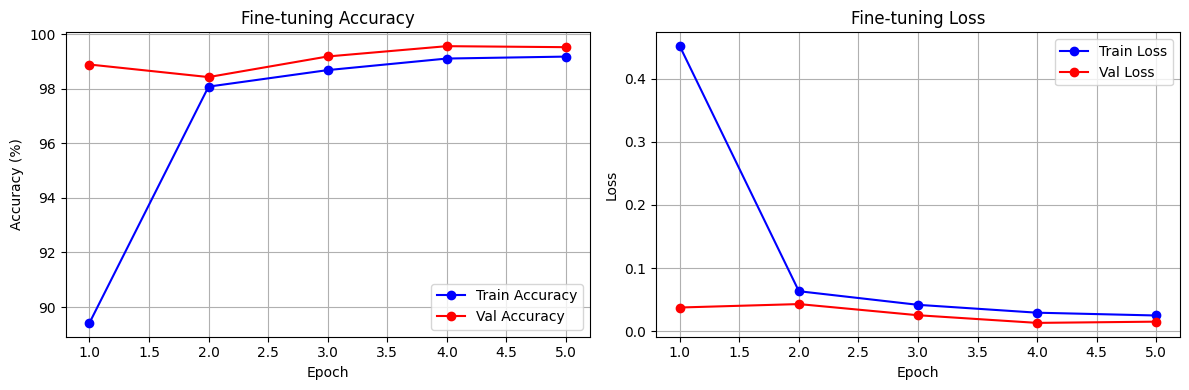

In [8]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_acc"], "b-o", label="Train Accuracy")
ax1.plot(epochs, history["val_acc"],   "r-o", label="Val Accuracy")
ax1.set_title("Fine-tuning Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history["train_loss"], "b-o", label="Train Loss")
ax2.plot(epochs, history["val_loss"],   "r-o", label="Val Loss")
ax2.set_title("Fine-tuning Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("finetune_curves.png", dpi=150)
plt.show()

In [ ]:
# Download model directly to your laptop
from google.colab import files
torch.save(model.state_dict(), "best_model.pth")
files.download("best_model.pth")